# <font size = 8 color ='336EFF'>kMeans</font>

Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython import display
%matplotlib inline

Simple Functions

In [ ]:
# A helper function to calculate the Euclidean diatance between the data
# points and the centroids
def calculate_distance(centroid, X, Y):
    distances = []
    # Unpack the x and y coordinates of the centroid
    c_x, c_y = centroid
    # Iterate over the data points and calculate the distance using the           # given formula
    for x, y in list(zip(X, Y)):
        root_diff_x = (x - c_x) ** 2
        root_diff_y = (y - c_y) ** 2
        distance = np.sqrt(root_diff_x + root_diff_y)
        distances.append(distance)

    return distances

In [ ]:
def plotCurrentSolution(Centers, data, labels):
    colors = ['r', 'g', 'b']
    # create a line plot of input vs result
    plt.clf()
    for n in range(Centers.shape[0]):
        idx = np.where(np.float64(n) == labels)
        plt.plot(data[idx, 0], data[idx, 1], '*', c=colors[n])
        plt.plot(Centers[n, 0], Centers[n, 1], '^', c=colors[n])
    # plot the sample as black circles
    plt.draw()#plt.show()
    display.display(plt.gcf())
    display.clear_output(wait=True)
    plt.pause(2)

kMeans function

In [ ]:
def kMeans_scratch(data, k):
    C = np.zeros((k, data.shape[1]))
    print(data.shape[1])
    for m in range(data.shape[1]):
        C[:, m] = np.random.rand(k)*(np.max(data[:, m]) - np.min(data[:, m])) + np.min(data[:, m])
    #C = np.array([[1., 1.], [7., 4.], [7., 1.]])
    print(C)
    labels = np.ones((data.shape[0], 1))
    oldLabels = labels.copy()

    noCenter = False
    while True:
        dis = []
        # Calculate the distances to the centers
        for n in range(C.shape[0]):
            dis.append(calculate_distance(C[n, :], data[:, 0], data[:, 1]))
        # Get the labels with the distances to the centers
        dista = np.array(dis)
        dista = np.transpose(dista)
        for n in range(data.shape[0]):
            temp = dista[n, :]
            labels[n] = np.argmin(temp) # select the label where the minimum is located
        # Update the centers with the mean or randomly
        for n in range(C.shape[0]):
            idx = np.where(np.float64(n) == labels)
            samples = data[idx[0], :]
            if samples.shape[0] > 0:
                C[n, :] = np.mean(samples, axis = 0)
            else:
                noCenter = True
                for m in range(1, data.shape[1]):
                    C[n, m-1] = np.random.rand(1)*(np.max(data[:, m]) - np.min(data[:, m])) + np.min(data[:, m])
        # Plot current solution
        plotCurrentSolution(C, data, labels)
        # Stoping Criteria
        if all(oldLabels == labels) and not noCenter:
            break
        else:
            oldLabels = labels.copy()
            noCenter = False

    return C, labels, dista

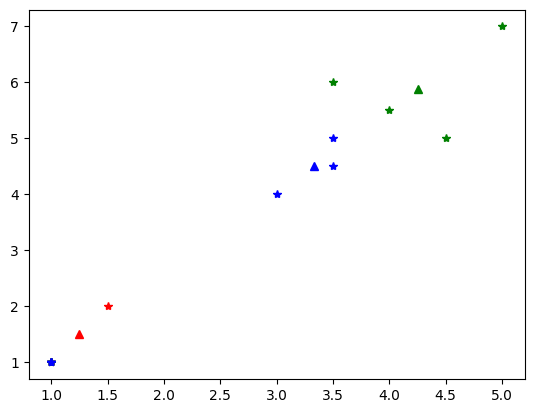

     Obj  XValue  YValue    C1_dis    C2_dis    C3_dis  labels
1.0  1.0     1.0     1.0  0.559017  5.859021  4.206476     0.0
2.0  2.0     1.5     2.0  0.559017  4.751644  3.100179     0.0
3.0  3.0     3.0     4.0  3.051639  2.253470  0.600925     2.0
4.0  4.0     5.0     7.0  6.656763  1.352082  3.004626     1.0
5.0  5.0     3.5     5.0  4.160829  1.152443  0.527046     2.0
6.0  6.0     4.5     5.0  4.776243  0.910014  1.269296     1.0
7.0  7.0     3.5     4.5  3.750000  1.566246  0.166667     2.0
8.0  8.0     4.0     5.5  4.854122  0.450694  1.201850     1.0
9.0  9.0     3.5     6.0  5.031153  0.760345  1.509231     1.0


In [ ]:
data = np.array( [[1, 1.0, 1.0],
[2, 1.5, 2.0],
[3, 3.0, 4.0],
[4, 5.0, 7.0],
[5, 3.5, 5.0],
[6, 4.5, 5.0],
[7, 3.5, 4.5],
[8, 4.0, 5.5],
[9, 3.5, 6.0],
] )

centers, labels, distances = kMeans_scratch(data[:, 1:], k = 3)
# Preview the data
headers = list(['Obj', 'XValue', 'YValue', 'C1_dis', 'C2_dis', 'C3_dis', 'labels'])
fra = pd.DataFrame(np.concatenate([data, distances, labels], axis=1),
                  index = list(data[:, 0]), columns = headers)
print(fra)